## Chaotic Pendulum

In [8]:
import mujoco
import time 
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()

""

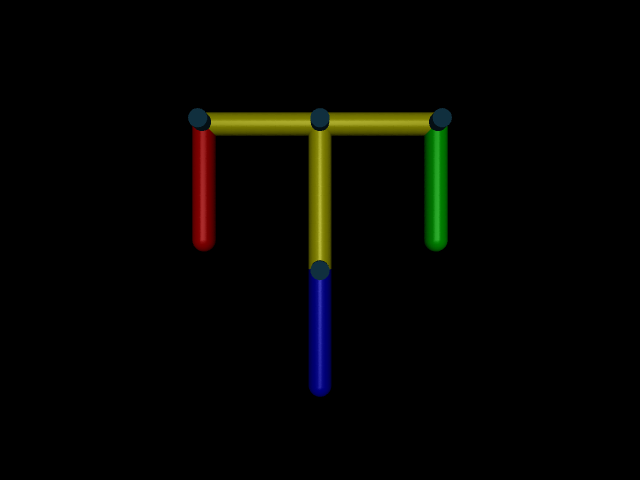

In [9]:
model = mujoco.MjModel.from_xml_path("chaotic_pendulum.xml")
data = mujoco.MjData(model)
height = 480
width = 640

# turn on joint visualization
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

with mujoco.Renderer(model, height, width) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera="fixed", scene_option=scene_option)

    media.show_image(renderer.render())

In [11]:
# setup for creating a video and timing components
n_seconds = 6 # seconds
framerate = 30 # HZ
n_frames = int(n_seconds * framerate)
frames = []
height = 240
width = 320

# set the initial state
mujoco.mj_resetData(model,data)
data.joint('root').qvel = 10

# simulate and record frames
frame = 0
sim_time = 0
render_time = 0
n_steps = 0

with mujoco.Renderer(model, height, width) as renderer:
    for i in range(n_frames):
        for i in range(n_frames):
            while data.time*framerate < i:
                tic = time.time()
                mujoco.mj_step(model, data)
                sim_time += time.time() - tic
                n_steps +=1
            tic = time.time()
            renderer.update_scene(data, camera="fixed")
            frame = renderer.render()
            render_time += time.time() - tic
            frames.append(frame)

# print timing and play video
step_time = 1e6*sim_time/n_steps
step_fps = n_steps/sim_time
print(f'simulation: {step_time:5.3g} us/step ({step_fps:5.0f}Hz)')
frame_time =1e6*render_time/n_frames
frame_fps = n_frames/render_time
print(f'rendering: {frame_time:5.3g} us/frame ({frame_fps:5.0f}Hz)')
print('\n')

# play the video
media.show_video(frames, fps=framerate)



simulation:  2.21 us/step (452136Hz)
rendering: 7.26e+04 us/frame (   14Hz)




This browser does not support the video tag.


/tmp/ipykernel_28620/1231484931.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  angle[i] = data.joint('root').qpos


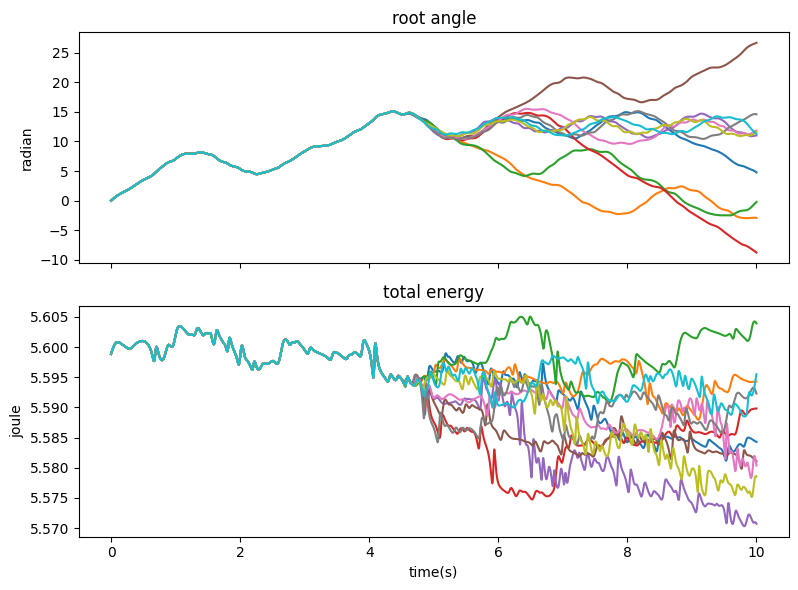

In [12]:
# chaos
PERTURBATION = 1e-7
SIM_DURATION = 10 # seconds
NUM_REPEATS = 10

# preallocate
n_steps = int(SIM_DURATION / model.opt.timestep)
sim_time = np.zeros(n_steps)
angle = np.zeros(n_steps)
energy = np.zeros(n_steps)

# prepare plotting axes
_, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# simulate NUM_REPEATS times with slightly different initial conditions
for _ in range(NUM_REPEATS):
    # initialize
    mujoco.mj_resetData(model, data)
    data.qvel[0] = 10 # root joint velocity
    # perturb the initial velocitys
    data.qvel[:] += PERTURBATION * np.random.randn(model.nv)

    #simulate
    for i in range(n_steps):
        mujoco.mj_step(model, data)
        sim_time[i] = data.time
        angle[i] = data.joint('root').qpos
        energy[i] = data.energy[0] + data.energy[1]

    # plot
    ax[0].plot(sim_time, angle)
    ax[1].plot(sim_time, energy)

# finalize plot
ax[0].set_title('root angle')
ax[0].set_ylabel('radian')
ax[1].set_title('total energy')
ax[1].set_ylabel('joule')
ax[1].set_xlabel('time(s)')
plt.tight_layout()



## Timestep size and accuracy

1000 steps at dt = 10ms
3162 steps at dt = 3.2ms
10000 steps at dt =  1ms
31622 steps at dt = 0.32ms
100000 steps at dt = 0.1ms


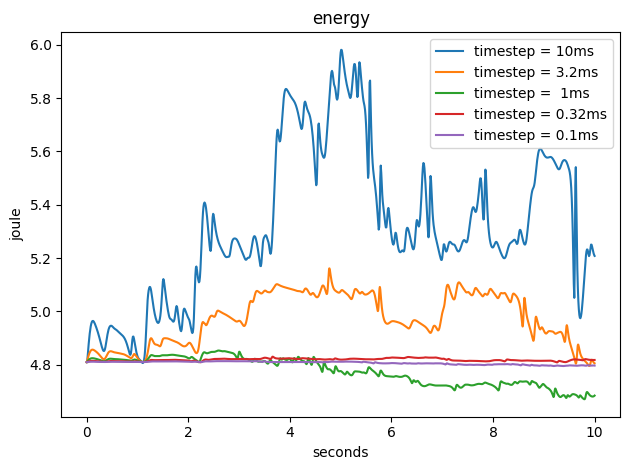

In [16]:
SIM_DURATION = 10 # seconds
TIMESTEPS = np.power(10, np.linspace(-2,-4, 5))

# prepare plotting axes
_, ax = plt.subplots(1,1)

for dt in TIMESTEPS:
    # set timestep, print
    model.opt.timestep = dt
    
    # allocate
    n_steps = int(SIM_DURATION / model.opt.timestep)
    sim_time = np.zeros(n_steps)
    energy = np.zeros(n_steps)

    # initialize
    mujoco.mj_resetData(model, data)
    data.qvel[0] = 9 # root joint velocity

    # simulate
    print('{} steps at dt = {:2.2g}ms'.format(n_steps, dt*1000))
    for i in range(n_steps):
        mujoco.mj_step(model, data)
        sim_time[i] = data.time
        energy[i] = data.energy[0] + data.energy[1]

    # plot 
    ax.plot(sim_time, energy, label='timestep = {:2.2g}ms'.format(dt*1000))

# finalize plot
ax.set_title('energy')
ax.set_ylabel('joule')
ax.set_xlabel('seconds')
ax.legend(frameon=True)
plt.tight_layout()



## Timestep size and Divergence

simulating 1000 steps at dt = 10ms

stopped due to divergence(mjWARN_BADQACC at timestep 385.

simulating 825 steps at dt = 12ms

stopped due to divergence(mjWARN_BADQACC at timestep 322.

simulating 681 steps at dt = 15ms
stopped due to divergence(mjWARN_BADQACC at timestep 166.


simulating 562 steps at dt = 18ms
stopped due to divergence(mjWARN_BADQACC at timestep 105.

simulating 464 steps at dt = 22ms


stopped due to divergence(mjWARN_BADQACC at timestep 84.

simulating 383 steps at dt = 26ms
stopped due to divergence(mjWARN_BADQACC at timestep 61.

simulating 316 steps at dt = 32ms

stopped due to divergence(mjWARN_BADQACC at timestep 45.




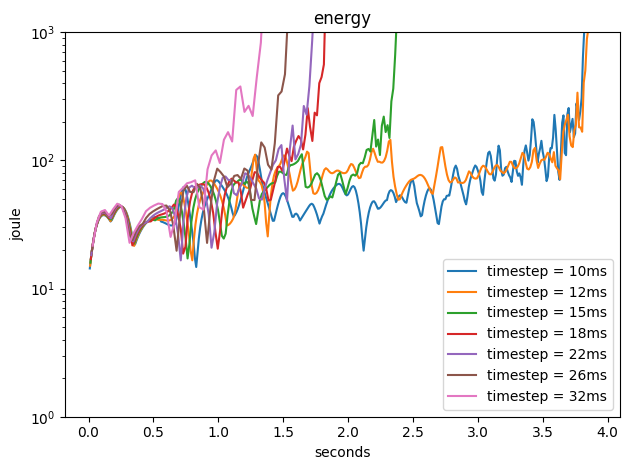

In [23]:
SIM_DURATION = 10 # seconds
TIMESTEPS = np.power(10, np.linspace(-2, -1.5, 7))

# plotting axes
ax = plt.gca()

for dt in TIMESTEPS:
    # set timestep size in model
    model.opt.timestep = dt

    # allocate
    n_steps = int(SIM_DURATION / model.opt.timestep)
    sim_time = np.zeros(n_steps)
    energy = np.zeros(n_steps)*np.nan
    speed = np.zeros(n_steps)*np.nan

    # initialize
    mujoco.mj_resetData(model, data)
    data.qvel[0] = 11 # set root joint velocity

    # simulate 
    print('simulating {} steps at dt = {:2.2g}ms'.format(n_steps, 1e3*dt))
    for i in range(n_steps):
        mujoco.mj_step(model, data)
        if data.warning.number.any():
            warning_index = np.nonzero(data.warning.number)[0][0]
            warning= mujoco.mjtWarning(warning_index).name
            print(f'stopped due to divergence({warning} at timestep {i}.\n')
            break
        sim_time[i] = data.time
        energy[i] = sum(abs(data.qvel))
        speed[i] = np.linalg.norm(data.qvel)
    
    # plot
    ax.plot(sim_time, energy, label='timestep = {:2.2g}ms'.format(1e3*dt))
    ax.set_yscale('log')

# finalize plot
ax.set_ybound(1, 1e3)
ax.set_title('energy')
ax.set_xlabel('seconds')
ax.set_ylabel('joule')
ax.legend(frameon=True, loc='lower right')
plt.tight_layout()



# Box and Sphere Contacts